In [1]:
import pandas as pd 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ipl_dataset.csv')
df

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,...,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
0,1,"Abdulla, YA",2,SA,KXIP,Allrounder,0,0,0,0.00,...,0.00,0,307,15,20.47,8.90,13.93,2009,50000,50000
1,2,Abdur Razzak,2,BAN,RCB,Bowler,214,18,657,71.41,...,0.00,0,29,0,0.00,14.50,0.00,2008,50000,50000
2,3,"Agarkar, AB",2,IND,KKR,Bowler,571,58,1269,80.62,...,121.01,5,1059,29,36.52,8.81,24.90,2008,200000,350000
3,4,"Ashwin, R",1,IND,CSK,Bowler,284,31,241,84.56,...,76.32,0,1125,49,22.96,6.23,22.14,2011,100000,850000
4,5,"Badrinath, S",2,IND,CSK,Batsman,63,0,79,45.93,...,120.71,28,0,0,0.00,0.00,0.00,2011,100000,800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,126,"Yadav, AS",2,IND,DC,Batsman,0,0,0,0.00,...,125.64,2,0,0,0.00,0.00,0.00,2010,50000,750000
126,127,Younis Khan,2,PAK,RR,Batsman,6398,7,6814,75.78,...,42.85,0,0,0,0.00,0.00,0.00,2008,225000,225000
127,128,Yuvraj Singh,2,IND,KXIP+,Batsman,1775,9,8051,87.58,...,131.88,67,569,23,24.74,7.02,21.13,2011,400000,1800000
128,129,Zaheer Khan,2,IND,MI+,Bowler,1114,288,790,73.55,...,91.67,1,1783,65,27.43,7.75,21.26,2008,200000,450000


In [3]:
df.isnull().sum()

Sl.NO.           0
PLAYER NAME      0
AGE              0
COUNTRY          0
TEAM             0
PLAYING ROLE     0
T-RUNS           0
T-WKTS           0
ODI-RUNS-S       0
ODI-SR-B         0
ODI-WKTS         0
ODI-SR-BL        0
CAPTAINCY EXP    0
RUNS-S           0
HS               0
AVE              0
SR-B             0
SIXERS           0
RUNS-C           0
WKTS             0
AVE-BL           0
ECON             0
SR-BL            0
AUCTION YEAR     0
BASE PRICE       0
SOLD PRICE       0
dtype: int64

In [4]:
numerical_cols = df.select_dtypes(include=[int, float]).drop(columns = ['Sl.NO.']).columns
numerical_cols

Index(['AGE', 'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS',
       'ODI-SR-BL', 'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS',
       'RUNS-C', 'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR',
       'BASE PRICE', 'SOLD PRICE'],
      dtype='object')

In [5]:
corr_matrix = df[numerical_cols].corr()
corr_matrix

,AGE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,...,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
AGE,1.000000,0.469402,0.293473,0.403131,0.038531,0.306949,-0.093574,0.323228,0.002776,0.083028,...,-0.020303,-0.070133,-0.203835,-0.170092,-0.300514,-0.236669,-0.282870,-0.254737,0.209273,-0.106201
T-RUNS,0.469402,1.000000,0.026285,0.892823,0.231411,0.045505,0.067700,0.690647,0.410143,0.411209,...,0.114298,0.216571,-0.253083,-0.277157,-0.298999,-0.329022,-0.309105,-0.222680,0.437984,0.216752
T-WKTS,0.293473,0.026285,1.000000,-0.088276,0.012052,0.822940,0.060641,0.088782,-0.218544,-0.268432,...,-0.147752,-0.198036,0.297302,0.289735,0.162456,0.117530,0.205208,-0.268438,0.216648,0.035767
ODI-RUNS-S,0.403131,0.892823,-0.088276,1.000000,0.319264,0.056554,0.126795,0.714058,0.523955,0.495765,...,0.194111,0.376012,-0.268950,-0.302745,-0.225109,-0.249795,-0.237517,-0.201213,0.388967,0.337834
ODI-SR-B,0.038531,0.231411,0.012052,0.319264,1.000000,0.160114,0.284584,0.291373,0.306338,0.360086,...,0.375371,0.320041,0.004855,-0.022502,0.018958,-0.019067,0.017522,-0.212726,0.287357,0.226880
ODI-WKTS,0.306949,0.045505,0.822940,0.056554,0.160114,1.000000,0.124361,0.077536,-0.198101,-0.209109,...,-0.030404,-0.148722,0.327122,0.302466,0.217302,0.230221,0.259800,-0.290655,0.204650,0.112327
ODI-SR-BL,-0.093574,0.067700,0.060641,0.126795,0.284584,0.124361,1.000000,0.103315,-0.027772,-0.067615,...,-0.051684,-0.033616,0.196887,0.151594,0.416627,0.313295,0.402495,0.009421,0.108670,0.075408
CAPTAINCY EXP,0.323228,0.690647,0.088782,0.714058,0.291373,0.077536,0.103315,1.000000,0.352422,0.392749,...,0.176919,0.254991,-0.277903,-0.300074,-0.183775,-0.248974,-0.198688,-0.226568,0.450316,0.318835
RUNS-S,0.002776,0.410143,-0.218544,0.523955,0.306338,-0.198101,-0.027772,0.352422,1.000000,0.834631,...,0.380022,0.866213,-0.160762,-0.220959,-0.101818,-0.179459,-0.118567,-0.008742,0.178185,0.478510
HS,0.083028,0.411209,-0.268432,0.495765,0.360086,-0.209109,-0.067615,0.392749,0.834631,1.000000,...,0.531028,0.788439,-0.235327,-0.291494,-0.176049,-0.254494,-0.192990,-0.054119,0.234347,0.347473


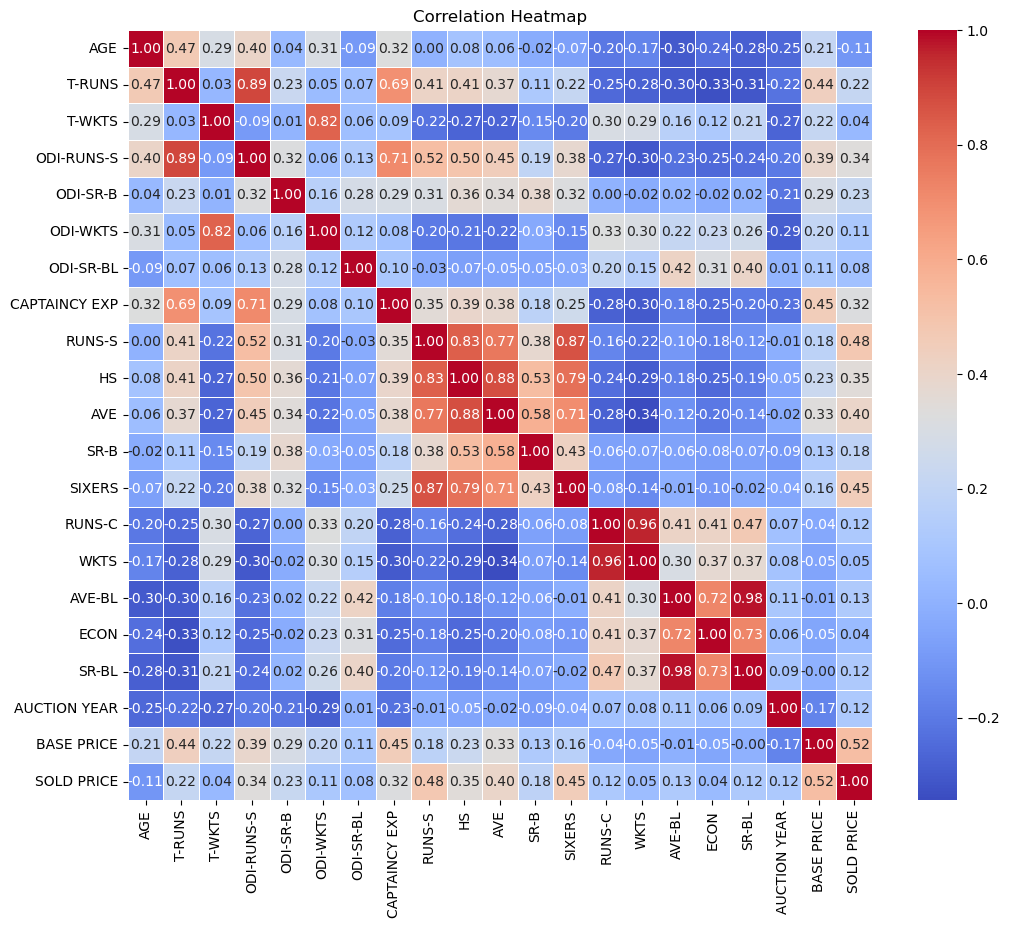

In [6]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='0.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [7]:
X = df.drop(columns=['Sl.NO.', 'PLAYER NAME', 'COUNTRY', 'TEAM', 'PLAYING ROLE', 'SOLD PRICE'])
y = df['SOLD PRICE']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [15]:
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)

Coefficients: [-7.25299431e+04 -5.12125280e+01 -3.81278341e+02  4.34548340e+01
 -3.05185793e+02  7.50716622e+02 -7.43285990e+02  8.33333146e+04
  3.24672249e+02 -4.10551367e+03  7.60965200e+03 -3.95402940e+02
  1.28050375e+03  1.84186351e+02 -1.10316535e+03  5.86080327e+03
 -5.96330253e+03 -7.68664599e+03  6.43455208e+04  1.32373406e+00]
Intercept: -128985330.47408217


In [16]:
print(f'Root Mean Square Error (Training): {root_mean_squared_error(y_train, y_train_pred) : .3f}')
print(f'Root Mean Square Error (Testing): {root_mean_squared_error(y_test, y_test_pred) : .3f}')

Root Mean Square Error (Training):  249842.520
Root Mean Square Error (Testing):  288103.526
